In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("powerplant_data.csv")
# AT = temperature
# v = vaccum
# ap = pressure
# eh = humidity

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE",axis = 1)
y = df["PE"]

In [6]:
#split out data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42
)

In [7]:
df.shape

(9568, 5)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [9]:
#build a tensor 
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [10]:
from torch.utils.data import TensorDataset,DataLoader
#for tensor dataset 
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
testing_dataset = TensorDataset(X_test_tensor,y_test_tensor)

#for dataloader
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(testing_dataset,batch_size=32)

## Deep learning

In [11]:
#Define ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model= nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),


            #output layer
            nn.Linear(6,1),
        )


    #logic for forward propagation
    def forward(self,x):
        return self.model(x)

In [12]:
import torch.optim as optim
model = ANN()

#define loss and optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [13]:
#Train our ann model through multiple epochs

train_losses = []
validation_losses  = []

best_val_loss = float("inf")
epochs=100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #total training loss for 1 epoch

    for xb,yb in train_loader:
        #xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        #forward propagation
        outputs = model(xb) #predicted output for this batch

        #compute loss
        loss = crietrion(outputs,yb)

        #back propagation compute loss
        loss.backward()

        #update paramas
        optimizer.step()

        running_loss += loss.item() #loss is a tensor ==> py float
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    #Validation
    model.eval()
    running_val_loss = 0.0
    

    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs,yb)
            running_val_loss += loss.item() 

    epoch_val_loss = running_val_loss/len(test_loader)
    validation_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs} ==> training loss = ${epoch_train_loss} & validation loss = ${epoch_val_loss}")



    #saving the best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") #pt or .pth


    

epoch $1/100 ==> training loss = $205759.96276041667 & validation loss = $203691.47526041666
epoch $2/100 ==> training loss = $197723.20579427082 & validation loss = $188324.25260416666
epoch $3/100 ==> training loss = $172303.32923177083 & validation loss = $151968.24505208334
epoch $4/100 ==> training loss = $124172.11650390625 & validation loss = $95516.79479166666
epoch $5/100 ==> training loss = $70894.30315755209 & validation loss = $49814.68053385417
epoch $6/100 ==> training loss = $36569.75289713542 & validation loss = $26378.464908854166
epoch $7/100 ==> training loss = $20935.51564941406 & validation loss = $16415.53204752604
epoch $8/100 ==> training loss = $13932.922306315104 & validation loss = $11540.139811197916
epoch $9/100 ==> training loss = $10021.008825683593 & validation loss = $8336.447330729166
epoch $10/100 ==> training loss = $7224.333040364583 & validation loss = $5933.812312825521
epoch $11/100 ==> training loss = $5119.717225138346 & validation loss = $4158

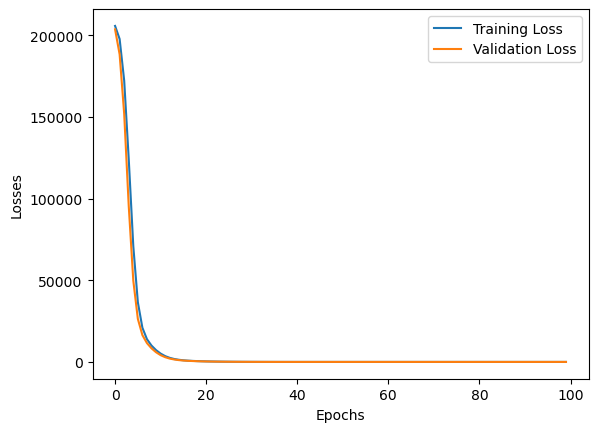

In [14]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":validation_losses
})
# plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"],label = "Training Loss")
plt.plot(loss_df["Validation Loss"],label ="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [15]:
#loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [16]:
#evaluate
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds,y_train_tensor)
    test_mse_loss = crietrion(test_preds,y_test_tensor)

print("Training MSE: ", train_mse_loss.item())
print("Testing MSE",test_mse_loss.item())

from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test,test_preds))

Training MSE:  20.492340087890625
Testing MSE 18.642305374145508
r^2 score = 0.9348499512221092


In [17]:
predicted_df = pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values,columns=["Actual Values"])
pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,434.731812,433.27
1,436.423645,438.16
2,460.890564,458.42
3,475.934296,480.82
4,434.902832,441.41
...,...,...
1909,450.799103,456.70
1910,431.073517,438.04
1911,467.270844,467.80
1912,430.541107,437.14
